In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configurable paths

# NT-level chec-seq binding score (MNase cut locations)
signal_folders = ["prom_signals/"]

# FIMO results
fimo_path = "fimo_results/promoters/fimo.tsv"

## Imports

In [3]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import cm

## Helper Functions

In [4]:
# Look for {replicate}_signals.gz (parquet) under any of the folders. Returns full file path or raises FileNotFoundError.
def find_signal_file(replicate: str, folder_paths: List[str]) -> str:
    filename = f"{replicate}_signals.gz"
    for folder in folder_paths:
        file_path = os.path.join(folder, filename)
        if os.path.exists(file_path):
            return file_path
    raise FileNotFoundError(f"Signal file for {replicate} not found in any provided folder.")

## Data Loading and Analysis

In [5]:
def load_signal_files_grouped(
    replicates_by_sample: Dict[str, List[str]],
    folder_paths: List[str],
) -> Dict[Tuple[str, str], pd.DataFrame]:
    """
    For each sample -> [replicates], load each replicate's DataFrame.
    Returns a dict keyed by (sample, replicate) -> DataFrame.
    """
    loaded: Dict[Tuple[str, str], pd.DataFrame] = {}
    for sample, reps in replicates_by_sample.items():
        for rep in reps:
            path = find_signal_file(rep, folder_paths)
            df = pd.read_parquet(path)
            loaded[(sample, rep)] = df
    return loaded

In [6]:
def choose_promoters(
    loaded_signals: dict,
    promoters: list[str] | None = None,
    n_top_promoters: int = 10,
) -> list[str]:
    """
    Choose promoters to plot.
    - If `promoters` provided: keep those found in any DataFrame.
    - Else: take top-N promoters by summed signal from first DataFrame.
    """
    if not loaded_signals:
        raise ValueError("No signals loaded.")

    first_df = next(iter(loaded_signals.values()))

    if promoters is None:
        ranked = first_df.copy()
        ranked["row_sum"] = ranked.sum(axis=1, numeric_only=True)
        ranked = ranked.sort_values("row_sum", ascending=False).drop(columns="row_sum", errors="ignore")
        chosen = list(ranked.index[:n_top_promoters])
        if not chosen:
            raise ValueError("No promoters available to plot.")
        return chosen

    # validate provided promoters
    all_present = set()
    for df in loaded_signals.values():
        all_present.update(df.index.intersection(promoters))
    chosen = [p for p in promoters if p in all_present]
    missing = [p for p in promoters if p not in all_present]
    if missing:
        print(f"Warning: promoters not found and skipped: {missing}")
    if not chosen:
        raise ValueError("None of the provided promoters were found.")
    return chosen

In [7]:
# Given a Series of signal values (right-aligned with leading NaNs), return only the valid (non-NA) segment starting at the first non-NA.
def valid_segment(row: pd.Series) -> np.ndarray:
    v = row.to_numpy(dtype=float, copy=False)
    if v.size == 0:
        return np.array([], dtype=float)
    mask = ~np.isnan(v)
    if not mask.any():
        return np.array([], dtype=float)
    first = int(np.argmax(mask))  # index of first True
    return v[first:]

In [8]:
def motif_centers_for_promoter(
    fimo: pd.DataFrame,
    motif_id: str,
    promoter: str,
) -> List[float]:
    """
    Return center positions (0.5*(start+end)) of FIMO hits
    for given motif_id in a promoter.
    """
    hits = fimo[(fimo["motif_id"] == motif_id) & (fimo["sequence_name"] == promoter)]
    if hits.empty:
        return []
    return ((hits["start"].astype(float) + hits["stop"].astype(float)) / 2.0).tolist()

In [9]:
# Fixed color scheme for two samples (3 replicates each): - sample1: blue shades (closer together) - sample2: orange shades (closer together) Shades are closer in RGB and alpha for better balance/visibility.
def simple_color_scheme() -> dict[str, list[tuple[float, float, float, float]]]:
    blues = [
        (0.52, 0.70, 0.98, 0.70),  # light
        (0.46, 0.66, 0.96, 0.80),  # medium
        (0.40, 0.62, 0.94, 0.88),  # dark (soft)
    ]
    oranges = [
        (0.99, 0.78, 0.48, 0.70),  # light
        (0.97, 0.67, 0.32, 0.80),  # medium
        (0.93, 0.54, 0.18, 0.88),  # dark (soft)
    ]
    return {"sample1": blues, "sample2": oranges}

In [10]:
def plot_two_samples_split(
    loaded_signals: dict[tuple[str, str], pd.DataFrame],
    fimo: pd.DataFrame,
    motif_ids: list[str],
    promoters: list[str] | None = None,
    n_top_promoters: int = 10,
    center_offset: int = 150,
    figsize_per_promoter: tuple[float, float] = (5, 0.8),
    line_width: float = 1.2,
    motif_labels: dict[str, str] | None = None,
    swap_upper_lower: bool = False,
):

    """
    Plot up to two samples (each with up to three replicates), but split the y-axis:
      - Sample 1 uses the bottom half (y=0 at axis bottom).
      - Sample 2 uses the top half (y=0 at mid-axis height).
    FIMO motifs are still shown as dots; x-axis handling and other behavior
    mirrors plot_two_samples_with_fimo().
    """
    if not loaded_signals:
        raise ValueError("No signals loaded.")
    if len(set(s for s, _ in loaded_signals.keys())) > 2:
        raise ValueError("Supports only two samples.")
    if not motif_ids:
        raise ValueError("Please provide at least one FIMO motif ID.")

    # Choose promoters as before
    chosen_promoters = choose_promoters(
        loaded_signals,
        promoters=promoters,
        n_top_promoters=n_top_promoters,
    )

    # Color maps
    color_scheme = simple_color_scheme()

    # Swap order so previously second sample becomes FIRST and gets the BLUE scheme
    original_samples = sorted({s for s, _ in loaded_signals.keys()})
    if len(original_samples) == 2:
        sample_names = [original_samples[1], original_samples[0]]
    else:
        sample_names = original_samples[:]
    bottom_sample = sample_names[0]
    if swap_upper_lower and len(sample_names) == 2:
        bottom_sample = sample_names[1]

    color_map = {
        s: color_scheme.get(f"sample{i+1}", [])
        for i, s in enumerate(sample_names)
    }

    # Dark motif colors (blue, red, ...)
    dark_palette = ["#0b3d91", "#8b0000", "#1f4e79", "#7f0000", "#123c69", "#5c0000"]
    motif_colors = {m: dark_palette[i % len(dark_palette)] for i, m in enumerate(motif_ids)}
    if motif_labels is None:
        motif_labels = {m: m for m in motif_ids}

    H = len(chosen_promoters)
    fig, axes = plt.subplots(
        H, 1,
        figsize=(figsize_per_promoter[0], figsize_per_promoter[1] * H),
        sharex=True,
        gridspec_kw={"hspace": 0.2},
    )
    if H == 1:
        axes = [axes]
    fig.subplots_adjust(hspace=0)

    # Collect per-panel x-limits for global alignment
    per_panel_limits = []

    for ax, promoter in zip(axes, chosen_promoters):
        template_df = next((df for df in loaded_signals.values() if promoter in df.index), None)
        if template_df is None:
            ax.set_title(f"{promoter} (not found)")
            per_panel_limits.append((np.nan, np.nan))
            continue

        seg_template = valid_segment(template_df.loc[promoter])
        if seg_template.size == 0:
            ax.set_title(f"{promoter} (no valid segment)")
            per_panel_limits.append((np.nan, np.nan))
            continue

        valid_len_template = seg_template.size
        tss_idx_template = valid_len_template - center_offset  # TSS index in valid coords

        # Track separate maxima for each sample (for half-height scaling)
        y_max_by_sample = {s: 0.0 for s in sample_names}

        # X-limits for alignment
        left_limit = -np.inf
        right_limit = -np.inf

        # First pass: compute maxima and x-limits, store segments to re-plot
        plotted_segments = {s: [] for s in sample_names}

        for s in sample_names:
            reps = [r for (samp, r) in loaded_signals if samp == s]
            shades = color_map[s]
            for rep, color in zip(reps, shades):
                df = loaded_signals[(s, rep)]
                if promoter not in df.index:
                    continue

                seg = valid_segment(df.loc[promoter])
                if seg.size == 0:
                    continue

                valid_len = seg.size
                tss_idx = valid_len - center_offset
                x_vals = np.arange(valid_len) - tss_idx

                ymax_seg = np.nanmax(seg)
                if np.isfinite(ymax_seg):
                    y_max_by_sample[s] = max(y_max_by_sample[s], float(ymax_seg))

                left_limit = max(left_limit, float(x_vals.min()))
                right_limit = max(right_limit, float(x_vals.max()))

                plotted_segments[s].append((x_vals, seg, color))

        # Determine half-height from the larger of the two maxima
        max_y = max(y_max_by_sample.values()) if y_max_by_sample else 0.0
        if max_y == 0.0:
            half_height = 1.2
        else:
            half_height = max_y * 1.15

        # Now actually plot, placing sample 1 in [0, half_height] and
        # sample 2 in [half_height, 2*half_height]
        for s in sample_names:
            y_offset = 0.0 if s == bottom_sample else half_height
            for x_vals, seg, color in plotted_segments[s]:
                ax.plot(x_vals, y_offset + seg, color=color, lw=line_width)


        # Vertical TSS line at x=0
        ax.axvline(0, color="#555", lw=0.8, alpha=0.5)

        # Horizontal baselines: bottom y=0 and (if second sample) mid y=half_height
        ax.axhline(0, color="#555", lw=0.6, alpha=0.5)
        if len(sample_names) >= 2:
            ax.axhline(half_height, color="#555", lw=0.6, alpha=0.7)

        # Set y-limits: two stacked halves
        ax.set_ylim(-0.04*half_height, 2 * half_height)

        # Motif dots near the top of the whole axis
        yk_top = 0.90 * (2 * half_height)
        for m in motif_ids:
            centers = motif_centers_for_promoter(fimo, m, str(promoter))
            if centers:
                centers = np.asarray(centers, dtype=float)
                xs = centers - tss_idx_template
                ax.scatter(xs, np.full(xs.size, yk_top), s=10,
                           color=motif_colors[m], alpha=0.95, zorder=5)

        # Remove y-ticks and labels as requested
        ax.set_yticks([])
        ax.set_yticklabels([])

        # Hide x-ticks/labels on all but bottom (sharex-safe)
        ax.tick_params(axis="both", labelsize=10)
        if ax is not axes[-1]:
            ax.tick_params(axis="x", which="both", labelbottom=False, bottom=False)

        ax.set_ylabel(promoter, fontsize=10)

        per_panel_limits.append((left_limit, right_limit))

        for spine in ax.spines.values():
            spine.set_linewidth(1.0)

    # Align x-axes across all subplots to the shortest promoter's left extent
    finite_limits = [(l, r) for (l, r) in per_panel_limits if np.isfinite(l) and np.isfinite(r)]
    if finite_limits:
        global_left = max(l for (l, r) in finite_limits)
        global_right = min(r for (l, r) in finite_limits)
        for ax in axes:
            ax.set_xlim(global_left, global_right)

    # Bottom axis: x-labels and label 0 as "TSS"
    bottom_ax = axes[-1]
    bottom_ax.set_xlabel("Position relative to TSS (bp)", fontsize=11)
    ticks = bottom_ax.get_xticks()
    if not np.any(np.isclose(ticks, 0)):
        ticks = np.append(ticks, 0.0)
        ticks.sort()
        bottom_ax.set_xticks(ticks)
    tick_labels = []
    for t in ticks:
        if np.isclose(t, 0.0):
            tick_labels.append("TSS")
        else:
            tick_labels.append(f"{int(t):d}" if np.isclose(t, round(t)) else f"{t:.0f}")
    bottom_ax.set_xticklabels(tick_labels, fontsize=10)

    # Combined legend (samples + motifs), centered at the top
    sample_handles = []
    sample_labels = []
    if len(sample_names) >= 1:
        sample_handles.append(
            Line2D([0], [0], color=color_scheme["sample1"][-1], lw=line_width + 0.6)
        )
        sample_labels.append(sample_names[0])  # bottom, blue
    if len(sample_names) >= 2:
        sample_handles.append(
            Line2D([0], [0], color=color_scheme["sample2"][-1], lw=line_width + 0.6)
        )
        sample_labels.append(sample_names[1])  # top, orange

    motif_handles = [
        Line2D([0], [0], marker="o", linestyle="None",
               color=motif_colors[m], label=motif_labels.get(m, m))
        for m in motif_ids
    ]
    motif_labels = [motif_labels.get(m, m) for m in motif_ids]

    all_handles = sample_handles + motif_handles
    all_labels = sample_labels + motif_labels
    if all_handles:
        fig.legend(
            all_handles, all_labels,
            loc="upper center", bbox_to_anchor=(0.5, 0.95),
            frameon=False,
            ncol=len(all_handles),
            fontsize=11,
            handletextpad=0.2,
            columnspacing=0.6,
            handlelength=1.4,
        )

    fig.tight_layout(rect=[0.02, 0.02, 0.98, 0.96])
    return fig

/tmp/ipykernel_3159523/572389888.py:198: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bottom_ax.set_xticklabels(tick_labels, fontsize=10)
/tmp/ipykernel_3159523/572389888.py:235: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.02, 0.02, 0.98, 0.96])


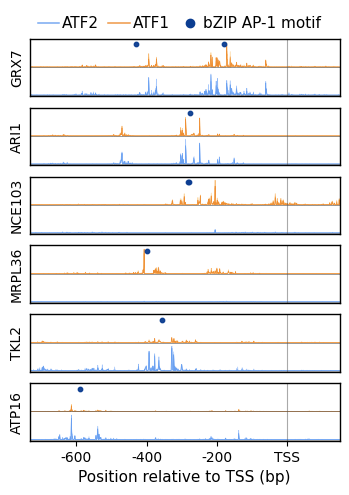

In [11]:
# Define your samples and replicates
replicates_by_sample = {
    "ATF1": ["ATF1_1_S4", "ATF1_2_S5", "ATF1_3_S6"],
    "ATF2":  ["ATF2_1_S10",  "ATF2_2_S11",  "ATF2_3_S12"],
}

# Folders with signal files
folders = [
    "/home/labs/barkailab/joshuabu/Joshua_20250227_FirstCheck/outfiles/results/prom_signals",
    "/home/labs/barkailab/joshuabu/Joshua_20250515_SecondSequencing/outfiles/results/prom_signals",
    "/home/labs/barkailab/joshuabu/Joshua_20250910_ThirdSequencing/outfiles/results/prom_signals"
]

# Load the data
loaded = load_signal_files_grouped(replicates_by_sample, folders)

# Load FIMO results (DataFrame with motif_id, start, end, sequence_name)
fimo = pd.read_csv("/home/labs/barkailab/joshuabu/fimo_all_motifs_all_proms/H12CORE_results/fimo.tsv", sep="\t")

# List of motifs to plot
motif_ids = ["BATF3.H12CORE.2.SM.B"]

# List of promoters to plot
promoters_to_plot = ["GRX7", "ARI1", "NCE103", "MRPL36", "TKL2", "ATP16"]

# Plot
fig = plot_two_samples_split(
    loaded_signals=loaded,
    fimo=fimo,
    motif_ids=motif_ids,
    motif_labels = {motif_ids[0]: "bZIP AP-1 motif"},
    promoters=promoters_to_plot,
    center_offset=150,
    figsize_per_promoter=(4, 0.87),
    line_width=0.5,
)

plt.show()